# Results Analysis

Multimodal Recommender System for E-Commerce Item Cold-Start

This notebook analyses the evaluation outputs produced in Phase 6. Every figure
is saved to `results/figures/` as it is generated, so the report and this
notebook draw on identical images.

All figures report the mean across five statistical seeds with error bars of one
standard deviation. Where two intervals overlap, the systems are not reliably
distinguishable.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT = Path.cwd().parent
TABLES = PROJECT / "results" / "tables"
FIGURES = PROJECT / "results" / "figures"
REPORTS = PROJECT / "reports"
LOGS = PROJECT / "logs"
FIGURES.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "font.size": 9,
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "grid.linewidth": 0.5,
    "legend.frameon": False,
})

DISPLAY = {
    "random": "Random",
    "popularity": "Popularity",
    "ncf": "NCF",
    "image_only": "Image only",
    "text_only": "Text only",
    "content_only": "Image + text",
    "interaction_image": "History + image",
    "interaction_text": "History + text",
    "concat_fusion": "Concat fusion",
    "attention_fusion": "Attention fusion",
}

COLOURS = {"anchor": "#9e9e9e", "collaborative": "#c44e52",
           "content": "#4c72b0", "fusion": "#55a868"}

def family(system):
    if system in ("random", "popularity"):
        return "anchor"
    if system == "ncf":
        return "collaborative"
    if system in ("concat_fusion", "attention_fusion"):
        return "fusion"
    return "content"

aggregate = pd.read_csv(TABLES / "evaluation_aggregate.csv")
print(f"{len(aggregate)} rows across "
      f"{aggregate['system'].nunique()} systems and "
      f"{aggregate['condition'].nunique()} conditions")

40 rows across 10 systems and 4 conditions


## 1. The dataset

The corpus was engineered in Phase 1 from the Amazon Reviews 2023 Electronics
category. The figures below summarise what the filtering produced.

In [2]:
statistics = pd.read_csv(REPORTS / "dataset_statistics.csv")
statistics.T.rename(columns={0: "value"})

,value
corpus_items,9503.0000
corpus_interactions,191763.0000
users,15794.0000
train_interactions,93701.0000
validation_interactions,15794.0000
test_interactions,15794.0000
ghost_interactions,25656.0000
ghost_items,1901.0000
train_density_pct,0.0786
popularity_gini,0.4633


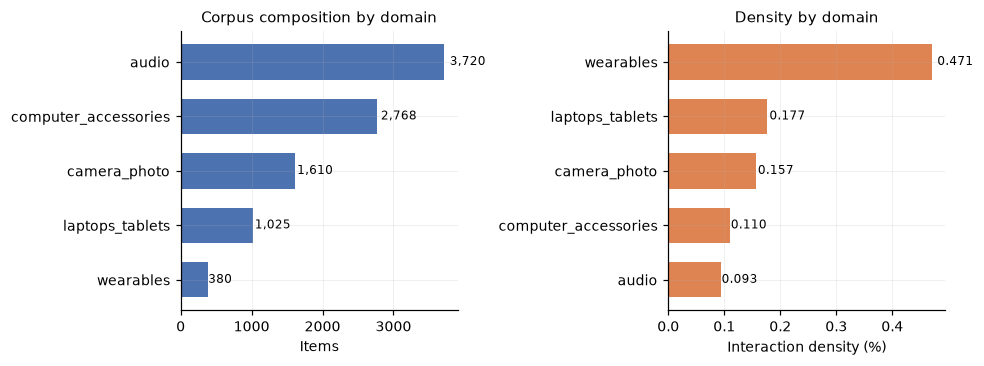

In [3]:
density = pd.read_csv(REPORTS / "domain_density.csv")

fig, axes = plt.subplots(1, 2, figsize=(9, 3.4))

order = density.sort_values("items", ascending=True)
axes[0].barh(order["domain"], order["items"], color="#4c72b0", height=0.65)
axes[0].set_xlabel("Items")
axes[0].set_title("Corpus composition by domain")
for y, value in enumerate(order["items"]):
    axes[0].text(value * 1.02, y, f"{value:,}", va="center", fontsize=8)

order = density.sort_values("density_pct", ascending=True)
axes[1].barh(order["domain"], order["density_pct"], color="#dd8452", height=0.65)
axes[1].set_xlabel("Interaction density (%)")
axes[1].set_title("Density by domain")
for y, value in enumerate(order["density_pct"]):
    axes[1].text(value * 1.02, y, f"{value:.3f}", va="center", fontsize=8)

fig.tight_layout()
fig.savefig(FIGURES / "dataset_composition.png")
plt.show()

The two panels are inversely ordered. Wearables is the smallest domain by item
count and the densest by interaction density; audio is the largest and the
sparsest. Domain size and representation quality are therefore distinct
properties, and per-domain performance differences should be read against
density rather than attributed to architecture alone.

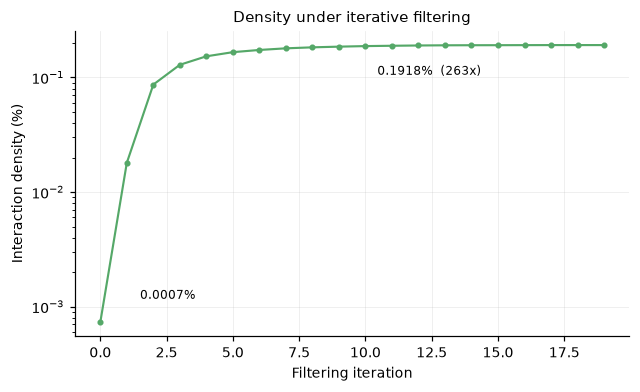

In [4]:
convergence = pd.read_csv(REPORTS / "iterative_filter_log.csv")

fig, ax = plt.subplots(figsize=(6.5, 3.6))
ax.plot(convergence["iteration"], convergence["density_pct"],
        marker="o", markersize=3, color="#55a868", linewidth=1.4)
ax.set_xlabel("Filtering iteration")
ax.set_ylabel("Interaction density (%)")
ax.set_title("Density under iterative filtering")
ax.set_yscale("log")

start = convergence["density_pct"].iloc[0]
end = convergence["density_pct"].iloc[-1]
ax.annotate(f"{start:.4f}%", xy=(0, start), xytext=(1.5, start * 1.6), fontsize=8)
ax.annotate(f"{end:.4f}%  ({end / start:.0f}x)",
            xy=(convergence["iteration"].iloc[-1], end),
            xytext=(convergence["iteration"].iloc[-1] * 0.55, end * 0.55), fontsize=8)

fig.savefig(FIGURES / "density_convergence.png")
plt.show()

Density rises by two orders of magnitude across the filtering iterations. The
curve flattens at convergence, which is the point at which a complete pass
removes nothing further and both constraints hold simultaneously.

## 2. Cold-start ranking

This is the project's central question: can a product with no purchase history
be recommended at all?

Cold-start items were withheld from training entirely. The models see them for
the first time at evaluation and must rank them from image and text alone.

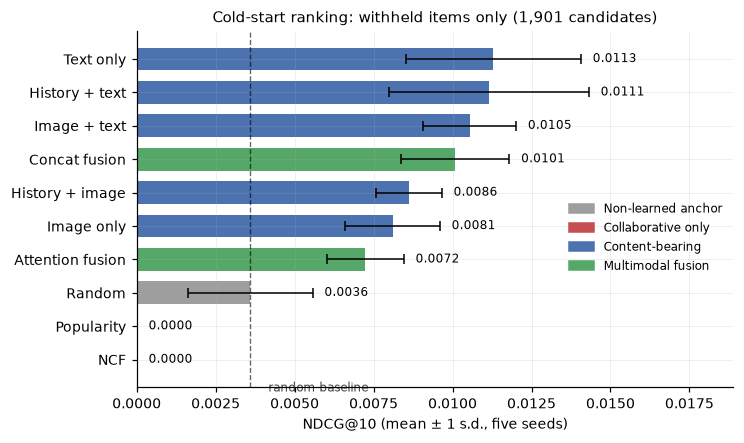

In [5]:
cold = (aggregate[(aggregate["condition"] == "cold_start")
                  & (aggregate["candidate_pool"] == "cold_only")]
        .sort_values("ndcg_mean"))

fig, ax = plt.subplots(figsize=(7, 4.2))
positions = np.arange(len(cold))
ax.barh(positions, cold["ndcg_mean"], xerr=cold["ndcg_std"],
        color=[COLOURS[family(s)] for s in cold["system"]],
        height=0.68, error_kw={"elinewidth": 1, "capsize": 3})
ax.set_yticks(positions)
ax.set_yticklabels([DISPLAY[s] for s in cold["system"]])

random_mean = float(cold.loc[cold["system"] == "random", "ndcg_mean"].iloc[0])
ax.axvline(random_mean, color="black", linestyle="--", linewidth=0.9, alpha=0.6)

limit = (cold["ndcg_mean"] + cold["ndcg_std"]).max() * 1.32
for position, (mean, spread) in enumerate(zip(cold["ndcg_mean"], cold["ndcg_std"])):
    ax.text(mean + spread + limit * 0.02, position, f"{mean:.4f}",
            va="center", fontsize=8)

ax.set_xlabel("NDCG@10 (mean ± 1 s.d., five seeds)")
ax.set_title("Cold-start ranking: withheld items only (1,901 candidates)")
ax.set_xlim(0, limit)
ax.annotate("random baseline", xy=(random_mean, -0.85),
            xytext=(random_mean + limit * 0.03, -0.85),
            fontsize=8, alpha=0.75, va="center", annotation_clip=False)

handles = [plt.Rectangle((0, 0), 1, 1, color=COLOURS[k])
           for k in ("anchor", "collaborative", "content", "fusion")]
ax.legend(handles, ["Non-learned anchor", "Collaborative only",
                    "Content-bearing", "Multimodal fusion"],
          loc="center right", fontsize=8, bbox_to_anchor=(1.0, 0.42))

fig.savefig(FIGURES / "cold_start_ranking.png")
plt.show()

In [6]:
table = cold.sort_values("ndcg_mean", ascending=False).copy()
table["multiple_of_random"] = (table["ndcg_mean"] / random_mean).round(1)
table["NDCG@10"] = (table["ndcg_mean"].map("{:.4f}".format) + " ± "
                    + table["ndcg_std"].map("{:.4f}".format))
table["system"] = table["system"].map(DISPLAY)
table[["system", "NDCG@10", "multiple_of_random"]].reset_index(drop=True)

,system,NDCG@10,multiple_of_random
0,Text only,0.0113 ± 0.0028,3.1
1,History + text,0.0111 ± 0.0032,3.1
2,Image + text,0.0105 ± 0.0015,2.9
3,Concat fusion,0.0101 ± 0.0017,2.8
4,History + image,0.0086 ± 0.0010,2.4
5,Image only,0.0081 ± 0.0015,2.2
6,Attention fusion,0.0072 ± 0.0012,2.0
7,Random,0.0036 ± 0.0020,1.0
8,Popularity,0.0000 ± 0.0000,0.0
9,NCF,0.0000 ± 0.0000,0.0


Two systems score **exactly zero**, with zero variance across all five seeds and
25,656 held-out interactions.

The popularity baseline ranks items by how often they were purchased during
training. A withheld item was purchased zero times, so it has no popularity and
cannot outrank any established item. Neural collaborative filtering learns an
embedding for each item from its interactions; a withheld item has none, so its
embedding is untrained and carries no information.

This is not poor performance. It is a structural inability, and it is the
problem the project set out to address.

The content-bearing systems reach up to three times the random baseline. They
are ranking products that have never been purchased, using only the product
photograph and the product description.

### The full catalogue is a harder question

The figure above ranks withheld items against each other. A deployed catalogue
is different: a new product competes against every established product on the
site, all of which carry purchase history it lacks.

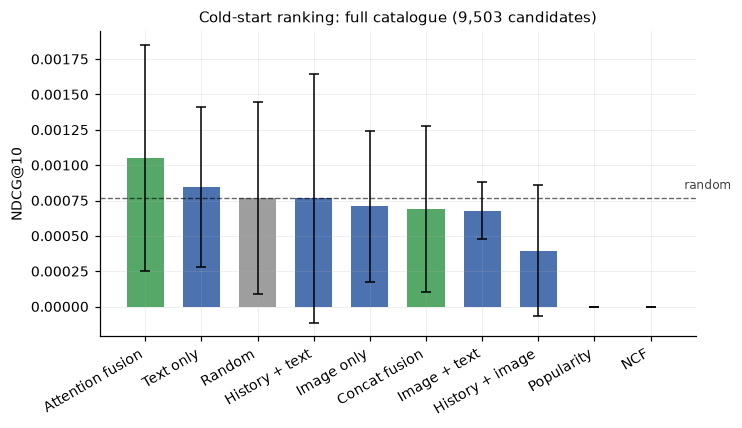

In [7]:
full = (aggregate[(aggregate["condition"] == "cold_start")
                  & (aggregate["candidate_pool"] == "full")]
        .sort_values("ndcg_mean", ascending=False))

fig, ax = plt.subplots(figsize=(7, 3.6))
positions = np.arange(len(full))
ax.bar(positions, full["ndcg_mean"], yerr=full["ndcg_std"],
       color=[COLOURS[family(s)] for s in full["system"]],
       width=0.66, error_kw={"elinewidth": 1, "capsize": 3})

random_mean_full = float(full.loc[full["system"] == "random", "ndcg_mean"].iloc[0])
ax.axhline(random_mean_full, color="black", linestyle="--", linewidth=0.9, alpha=0.6)
ax.text(len(full) - 0.4, random_mean_full * 1.08, "random", fontsize=8, alpha=0.75)

ax.set_xticks(positions)
ax.set_xticklabels([DISPLAY[s] for s in full["system"]], rotation=30, ha="right")
ax.set_ylabel("NDCG@10")
ax.set_title("Cold-start ranking: full catalogue (9,503 candidates)")

fig.savefig(FIGURES / "cold_start_full_catalogue.png")
plt.show()

Against the full catalogue, no system exceeds the random baseline once the error
bars are taken into account. Every content model's interval overlaps random's.

Ranking a brand-new product above 7,600 established ones is beyond all systems
tested here. Reporting both candidate pools is necessary: the restricted pool
shows that content signals carry real information, and the full catalogue shows
that this information is not yet sufficient for deployment.

## 3. All systems, all conditions

Four conditions were evaluated. **Control** uses every available signal.
**Blind** suppresses the image and **Silent** the text in the fully trained
model, measuring how far each system depends on a modality. **Cold-start**
evaluates the withheld items.

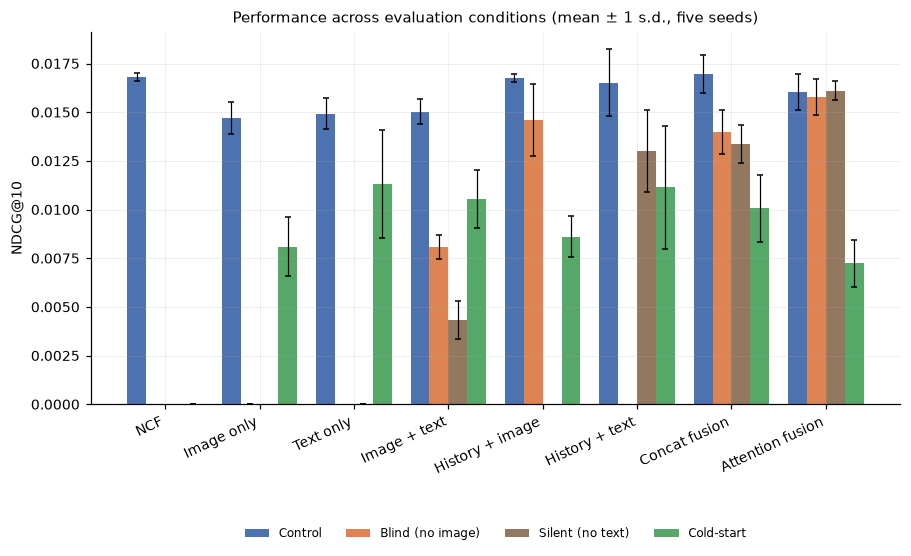

In [8]:
order = ["ncf", "image_only", "text_only", "content_only",
         "interaction_image", "interaction_text",
         "concat_fusion", "attention_fusion"]
conditions = [("control", "full", "Control"),
              ("blind", "full", "Blind (no image)"),
              ("silent", "full", "Silent (no text)"),
              ("cold_start", "cold_only", "Cold-start")]

fig, ax = plt.subplots(figsize=(9.5, 4.4))
width = 0.2
positions = np.arange(len(order))
palette = ["#4c72b0", "#dd8452", "#937860", "#55a868"]

for index, (condition, pool, label) in enumerate(conditions):
    subset = aggregate[(aggregate["condition"] == condition)
                       & (aggregate["candidate_pool"] == pool)]
    means = dict(zip(subset["system"], subset["ndcg_mean"]))
    spread = dict(zip(subset["system"], subset["ndcg_std"]))
    ax.bar(positions + index * width - 1.5 * width,
           [means.get(s, np.nan) for s in order], width,
           yerr=[spread.get(s, 0.0) for s in order],
           label=label, color=palette[index],
           error_kw={"elinewidth": 0.8, "capsize": 2})

ax.set_xticks(positions)
ax.set_xticklabels([DISPLAY[s] for s in order], rotation=25, ha="right")
ax.set_ylabel("NDCG@10")
ax.set_title("Performance across evaluation conditions (mean ± 1 s.d., five seeds)")
ax.legend(fontsize=8, ncol=4, loc="upper center", bbox_to_anchor=(0.5, -0.3))

fig.savefig(FIGURES / "condition_comparison.png")
plt.show()

In [9]:
pivot = (aggregate[aggregate["candidate_pool"].isin(["full", "cold_only"])]
         .assign(label=lambda d: d["condition"] + " / " + d["candidate_pool"])
         .pivot_table(index="system", columns="label", values="ndcg_mean")
         .reindex(order)
         .rename(index=DISPLAY)
         .round(4))
pivot

label,blind / full,cold_start / cold_only,cold_start / full,control / full,silent / full
system,,,,,
NCF,NaN,0.0000,0.0000,0.0168,NaN
Image only,0.0000,0.0081,0.0007,0.0147,NaN
Text only,NaN,0.0113,0.0008,0.0149,0.0000
Image + text,0.0081,0.0105,0.0007,0.0150,0.0043
History + image,0.0146,0.0086,0.0004,0.0167,NaN
History + text,NaN,0.0111,0.0008,0.0165,0.0130
Concat fusion,0.0140,0.0101,0.0007,0.0170,0.0134
Attention fusion,0.0158,0.0072,0.0010,0.0160,0.0161


## 4. Which modality does each system actually use?

The Blind and Silent conditions remove a modality from a model that was trained
with it. The size of the resulting drop measures how far the model relied on
that signal.

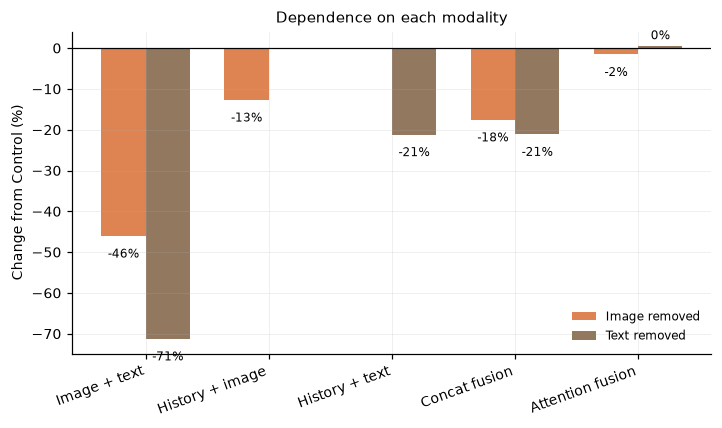

In [10]:
control = (aggregate[(aggregate["condition"] == "control")
                     & (aggregate["candidate_pool"] == "full")]
           .set_index("system")["ndcg_mean"])

rows = []
for condition, label in (("blind", "Image removed"), ("silent", "Text removed")):
    subset = aggregate[(aggregate["condition"] == condition)
                       & (aggregate["candidate_pool"] == "full")]
    for row in subset.itertuples():
        if row.system in control.index and control[row.system] > 0:
            rows.append({"system": row.system, "condition": label,
                         "change": (row.ndcg_mean - control[row.system])
                                   / control[row.system] * 100})

degradation = pd.DataFrame(rows)
present = [s for s in ["content_only", "interaction_image", "interaction_text",
                       "concat_fusion", "attention_fusion"]
           if s in set(degradation["system"])]

fig, ax = plt.subplots(figsize=(7.5, 3.8))
width = 0.36
positions = np.arange(len(present))

for index, (label, colour) in enumerate([("Image removed", "#dd8452"),
                                         ("Text removed", "#937860")]):
    values = (degradation[degradation["condition"] == label]
              .set_index("system")["change"])
    heights = [values.get(s, np.nan) for s in present]
    bars = ax.bar(positions + index * width - width / 2, heights, width,
                  label=label, color=colour)
    for bar, value in zip(bars, heights):
        if not np.isnan(value):
            ax.text(bar.get_x() + bar.get_width() / 2,
                    value - 3 if value < 0 else value + 1, f"{value:.0f}%",
                    ha="center", va="top" if value < 0 else "bottom", fontsize=8)

ax.axhline(0, color="black", linewidth=0.8)
ax.set_xticks(positions)
ax.set_xticklabels([DISPLAY[s] for s in present], rotation=20, ha="right")
ax.set_ylabel("Change from Control (%)")
ax.set_title("Dependence on each modality")
ax.legend(fontsize=8)

fig.savefig(FIGURES / "modality_dependence.png")
plt.show()

The two fusion designs behave very differently.

**Concatenation fusion** loses roughly a fifth of its performance when either
modality is removed, which indicates that both contribute materially to its
predictions.

**Attention fusion** is almost unaffected. Removing the text slightly *improved*
it. A model that does not degrade when a signal is removed was not using that
signal, so attention fusion is effectively operating on the interaction history
alone despite having access to both content modalities.

This corroborates the attention weights measured during tuning, which showed 70%
of the attention mass on the collaborative signal against 14% on image and 16%
on text. Two independent measurements agree, and together they explain why
attention fusion is the weakest content-bearing system under cold-start: its
content pathways never developed during training.

## 5. Stability across seeds

Each configuration was trained five times with different random seeds. The
spread across those runs distinguishes a stable result from a fluctuation of a
single run.

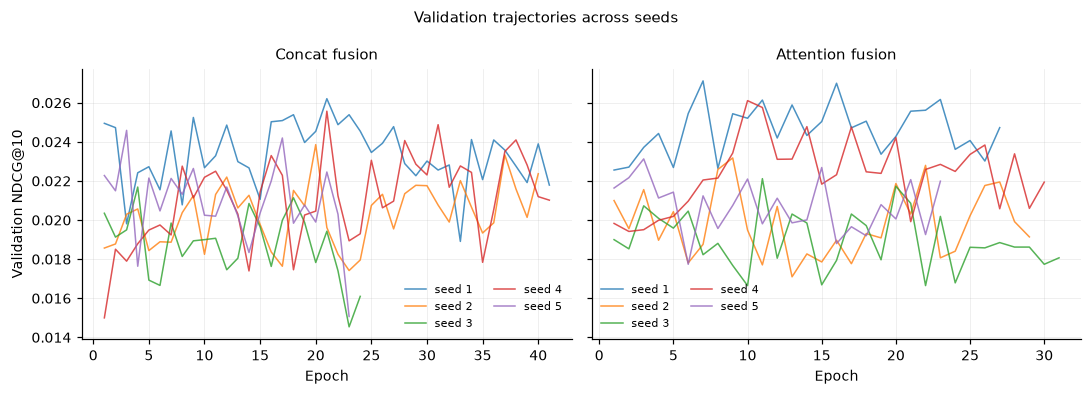

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.6), sharey=True)

for ax, system in zip(axes, ["concat_fusion", "attention_fusion"]):
    for seed in [1, 2, 3, 4, 5]:
        path = LOGS / f"{system}_seed{seed}.csv"
        if path.exists():
            log = pd.read_csv(path)
            ax.plot(log["epoch"], log["val_ndcg"], linewidth=1,
                    alpha=0.8, label=f"seed {seed}")
    ax.set_title(DISPLAY[system])
    ax.set_xlabel("Epoch")
    ax.legend(fontsize=7, ncol=2)

axes[0].set_ylabel("Validation NDCG@10")
fig.suptitle("Validation trajectories across seeds", fontsize=10)
fig.tight_layout()
fig.savefig(FIGURES / "learning_curves.png")
plt.show()

In [12]:
seeds = pd.read_csv(REPORTS / "seed_summary.csv")
seeds["system"] = seeds["system"].map(DISPLAY).fillna(seeds["system"])
seeds.sort_values("ndcg_mean", ascending=False).round(4).reset_index(drop=True)

,system,runs,ndcg_mean,ndcg_std,coverage_mean,coverage_std,epoch_mean
0,History + image,5,0.0248,0.0018,277.2,275.1385,31.6
1,Concat fusion,5,0.0244,0.0018,93.2,49.9370,13.8
2,Attention fusion,5,0.0243,0.0022,97.4,36.5144,8.0
3,History + text,5,0.0243,0.0010,175.6,147.9267,23.2
4,Image + text,5,0.0233,0.0016,122.2,77.8890,14.6
5,Text only,5,0.0230,0.0014,154.8,116.9239,21.0
6,NCF,5,0.0226,0.0017,222.8,206.5217,12.8
7,Image only,5,0.0222,0.0021,153.4,85.5529,18.4


The trajectories are noisy and the seeds separate substantially. This matters
for how results are selected: early stopping takes the maximum over epochs, and
the maximum of a noisy sequence is a biased estimator, since it selects for
upward fluctuation.

During tuning, one configuration reached a validation score 3.2 standard
deviations above its own five-seed mean. Reporting that run alone would have
overstated the configuration's performance by roughly a fifth. This is why every
figure in this notebook reports a mean with its spread rather than a best
run.

## 6. What the results show

**Collaborative filtering fails categorically on unseen items.** Popularity and
NCF score exactly zero, with zero variance, across five seeds and 25,656
interactions. The failure is structural rather than a matter of degree.

**Content signals provide measurable but modest cold-start capability.** Up to
three times the random baseline when withheld items are ranked against each
other. Against the full catalogue, no system reliably exceeds random.

**Text carries more cold-start signal than images.** This was predicted before
any model was trained: the Phase 2 feature validation measured a within-domain
separation of +0.257 for text against +0.102 for images.

**Multimodal fusion does not beat the best single content signal in this
regime.** Concatenation fusion and text alone are statistically indistinguishable
under cold-start. This is a negative result against the project's hypothesis and
is reported as such.

**Attention fusion under-develops its content pathways.** Evidenced independently
by attention weights and by modality suppression.

**Single-seed selection produces optimistically biased results.** Measured at up
to 3.2 standard deviations.

## 7. Where cold-start inference breaks down

The aggregate cold-start score describes the average across all withheld items.
It does not reveal whether performance is spread evenly or concentrated in a
few items. This section examines retrieval quality per item rather than per
user, using the strongest fusion model.

In [13]:
per_item = pd.read_csv(TABLES / "cold_start_per_item_concat_fusion_seed1.csv")

retrieved = per_item[per_item["mean_ndcg"] > 0]
print(f"withheld items          : {len(per_item):,}")
print(f"retrieved at least once : {len(retrieved):,} ({len(retrieved)/len(per_item):.1%})")
print(f"never retrieved         : {len(per_item)-len(retrieved):,} "
      f"({1-len(retrieved)/len(per_item):.1%})")
print(f"mean NDCG@10 overall    : {per_item['mean_ndcg'].mean():.4f}")
print(f"mean NDCG@10 if retrieved: {retrieved['mean_ndcg'].mean():.4f}")

withheld items          : 1,901
retrieved at least once : 52 (2.7%)
never retrieved         : 1,849 (97.3%)
mean NDCG@10 overall    : 0.0056
mean NDCG@10 if retrieved: 0.2063


Every user receives a list of ten recommendations, so only a limited number of
the 1,901 withheld items can occupy those positions across the evaluation. The
question is therefore not how many items are retrieved, but whether the items
that are retrieved differ systematically from those that are not.

In [14]:
per_item["retrieved"] = per_item["mean_ndcg"] > 0

comparison = (per_item.groupby("retrieved")
              .agg(items=("item_idx", "size"),
                   median_text_length=("text_length", "median"),
                   median_title_length=("title_length", "median"),
                   with_description=("has_description", "mean"),
                   with_image=("has_image", "mean"),
                   median_corpus_interactions=("corpus_interactions", "median"),
                   median_eval_interactions=("n_interactions", "median"))
              .round(3)
              .rename(index={False: "never retrieved", True: "retrieved"}))
comparison.T

retrieved,never retrieved,retrieved
items,1849.000,52.000
median_text_length,1580.000,1593.000
median_title_length,132.000,123.000
with_description,0.617,0.596
with_image,1.000,1.000
median_corpus_interactions,12.000,18.000
median_eval_interactions,9.000,12.000


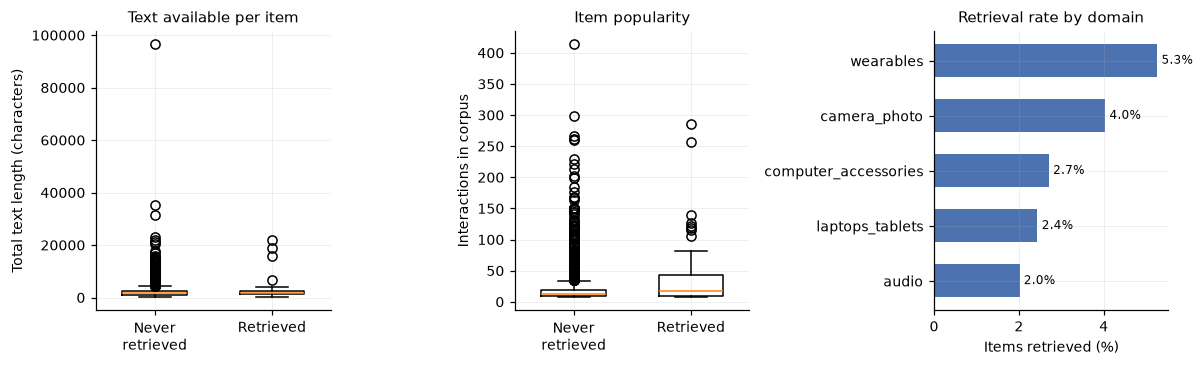

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(11, 3.4))

groups = [per_item.loc[~per_item["retrieved"], "text_length"],
          per_item.loc[per_item["retrieved"], "text_length"]]
axes[0].boxplot(groups, tick_labels=["Never\nretrieved", "Retrieved"], widths=0.55)
axes[0].set_ylabel("Total text length (characters)")
axes[0].set_title("Text available per item")

groups = [per_item.loc[~per_item["retrieved"], "corpus_interactions"],
          per_item.loc[per_item["retrieved"], "corpus_interactions"]]
axes[1].boxplot(groups, tick_labels=["Never\nretrieved", "Retrieved"], widths=0.55)
axes[1].set_ylabel("Interactions in corpus")
axes[1].set_title("Item popularity")

by_domain = (per_item.groupby("domain")["retrieved"].mean().sort_values() * 100)
axes[2].barh(by_domain.index, by_domain.values, color="#4c72b0", height=0.6)
axes[2].set_xlabel("Items retrieved (%)")
axes[2].set_title("Retrieval rate by domain")
for y, value in enumerate(by_domain.values):
    axes[2].text(value + 0.1, y, f"{value:.1f}%", va="center", fontsize=8)

fig.tight_layout()
fig.savefig(FIGURES / "cold_start_failure_analysis.png")
plt.show()

In [17]:
best = per_item.nlargest(10, "mean_ndcg")[
    ["title", "domain", "mean_ndcg", "median_rank", "text_length", "corpus_interactions"]]
best["title"] = best["title"].str.slice(0, 70)
best.reset_index(drop=True)

,title,domain,mean_ndcg,median_rank,text_length,corpus_interactions
0,"Azeyou 7 inch Android 11.0 Tablet for Kids, 2G...",laptops_tablets,0.842882,1.0,1434,10
1,OontZ Angle 3 Plus - Portable Bluetooth Speake...,audio,0.752296,1.0,1267,126
2,Sabrent 4-Port USB 3.0 Hub with Individual LED...,computer_accessories,0.623071,3.0,430,7
3,TOZO T9 True Wireless Earbuds Environmental No...,audio,0.471599,3.0,1486,55
4,Logitech HD Laptop Webcam C615 with Fold-and-G...,computer_accessories,0.457559,3.0,1062,139
5,Sennheiser CX 300S In Ear Headphone with One-B...,audio,0.445623,3.5,1089,12
6,Logitech Wireless Touch Keyboard K400 with Bui...,computer_accessories,0.437051,4.0,1441,7
7,"NORTH BISON Kids Tablet, 7 inch Android 11.0 T...",laptops_tablets,0.420764,3.0,2635,42
8,"Tablet for Kids, Kids Tablet 10.1 Inch, Androi...",laptops_tablets,0.367746,5.0,2190,22
9,Kids Tablet 10 inch Tablet for Kids with Case ...,laptops_tablets,0.367718,5.5,2947,9
